In [1]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

In [2]:
root = 'data/generated/'

In [3]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

def visualize_point_clouds(x_file, pos_file, batch_file):
    """
    Visualizes 3D point clouds stored in PyTorch .pt files with categorical colors for atom types
    and varying saturation for hybridization states.

    Args:
        x_file (str): Path to the .pt file containing point types (integers).
        pos_file (str): Path to the .pt file containing point positions (3D coordinates).
        batch_file (str): Path to the .pt file containing batch assignments (integers).
    """
    # Mapping of point types to atom and hybridization states
    type_mapping = {
        1: "(1, -1): H (unknown)",
        2: "(1, 0): H (s)",
        3: "(6, -1): C (unknown)",
        4: "(6, 1): C (sp)",
        5: "(6, 2): C (sp2)",
        6: "(6, 3): C (sp3)",
        7: "(7, -1): N (unknown)",
        8: "(7, 1): N (sp)",
        9: "(7, 2): N (sp2)",
        10: "(7, 3): N (sp3)",
        11: "(8, -1): O (unknown)",
        12: "(8, 2): O (sp2)",
        13: "(8, 3): O (sp3)",
        14: "(9, -1): F (unknown)",
        15: "(9, 3): F (sp3)"
    }

    # Define categorical colors for each atom type
    base_colors = {
        1: "blue",   # Hydrogen (H)
        6: "gray",   # Carbon (C)
        7: "green",  # Nitrogen (N)
        8: "red",    # Oxygen (O)
        9: "purple"  # Fluorine (F)
    }

    # Function to adjust color saturation for hybridization states
    def adjust_saturation(color, hybridization):
        """
        Adjusts the saturation of a base color based on the hybridization state.
        Args:
            color (str): Base color name or hex code.
            hybridization (int): Hybridization state (-1, 0, 1, 2, 3).
        Returns:
            str: Adjusted color in hex format.
        """
        base_color = mcolors.to_rgb(color)
        if hybridization == -1:  # Unknown
            factor = 0.3  # Low saturation
        elif hybridization == 0:  # s
            factor = 0.5
        elif hybridization == 1:  # sp
            factor = 0.7
        elif hybridization == 2:  # sp2
            factor = 0.85
        elif hybridization == 3:  # sp3
            factor = 1.0  # Full saturation
        adjusted_color = tuple(factor * c for c in base_color)
        return mcolors.to_hex(adjusted_color)

    # Load the data from .pt files
    x = torch.load(x_file).detach().cpu()  # Point types (integers)
    pos = torch.load(pos_file).detach().cpu()  # Point positions (3D coordinates)
    batch = torch.load(batch_file).detach().cpu()  # Batch assignments (integers)

    # Ensure the data is in the correct format
    assert pos.shape[1] == 3, "Positions should have 3 columns (x, y, z)."
    assert len(x) == len(pos) == len(batch), "Mismatch in data lengths."

    # Get the unique batch indices (graphs)
    unique_batches = torch.unique(batch)

    # Create a 3D plot for each graph
    for b in unique_batches:
        # Filter points belonging to the current batch
        mask = batch == b
        points = pos[mask]
        types = x[mask]

        # Map point types to colors
        colors = []
        for t in types:
            for key, value in type_mapping.items():
                if t.item() == key:
                    atom_number, hybridization = eval(value.split(":")[0])  # Extract (atomic_number, hybridization)
                    base_color = base_colors[atom_number]
                    colors.append(adjust_saturation(base_color, hybridization))
                    break

        # Create a 3D scatter plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=20)

        # Add legend for atom types and hybridization states
        legend_elements = []
        for key, value in type_mapping.items():
            atom_number, hybridization = eval(value.split(":")[0])  # Extract (atomic_number, hybridization)
            base_color = base_colors[atom_number]
            color = adjust_saturation(base_color, hybridization)
            legend_elements.append(Line2D([0], [0], marker='o', color='w', label=f'{value}', 
                                          markerfacecolor=color, markersize=8))
        ax.legend(handles=legend_elements, loc='upper right', title="Atom (Hybridization)")

        # Add labels and title
        ax.set_title(f'3D Point Cloud for Graph {b.item()}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        # Show the plot
        plt.show()

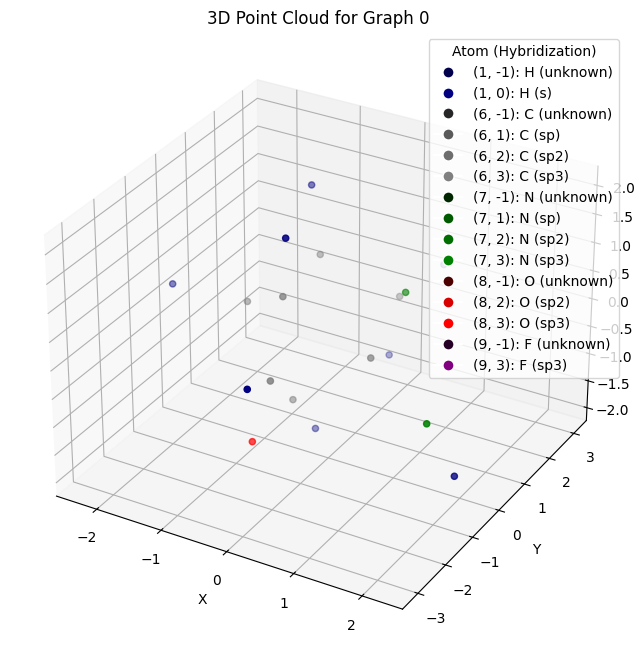

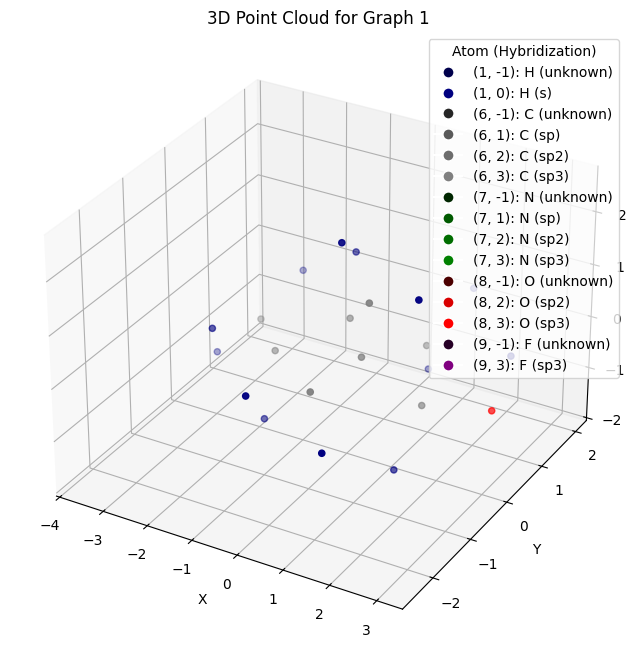

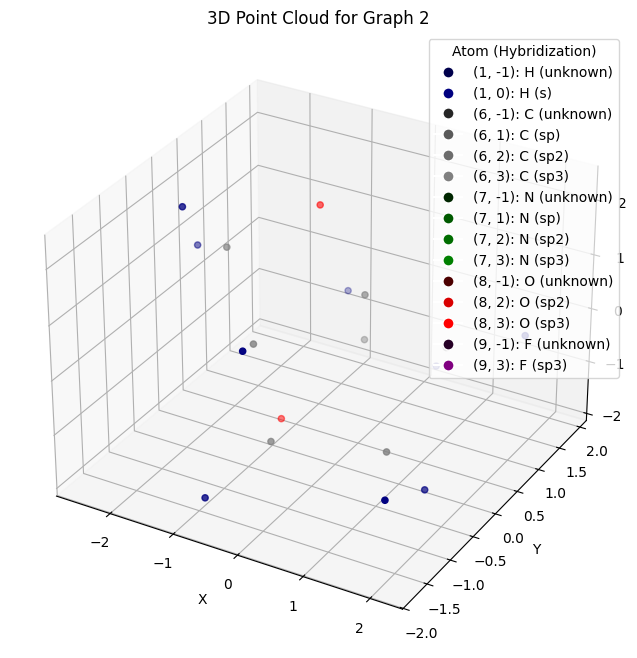

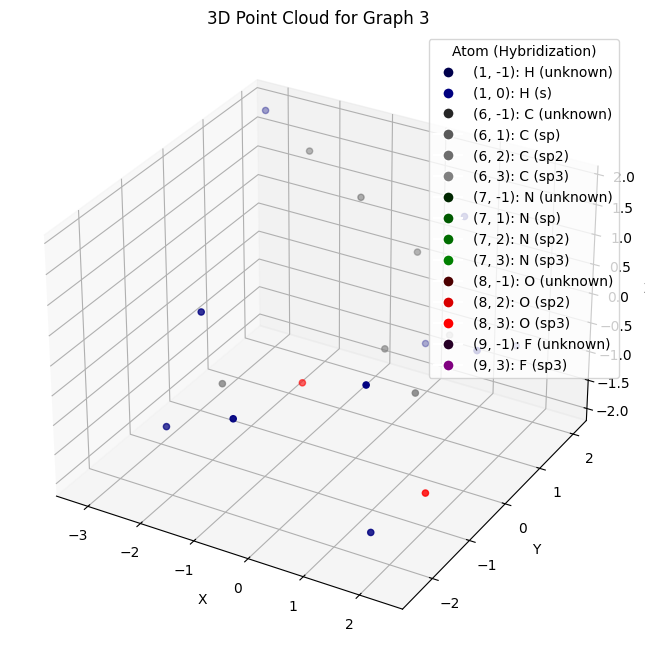

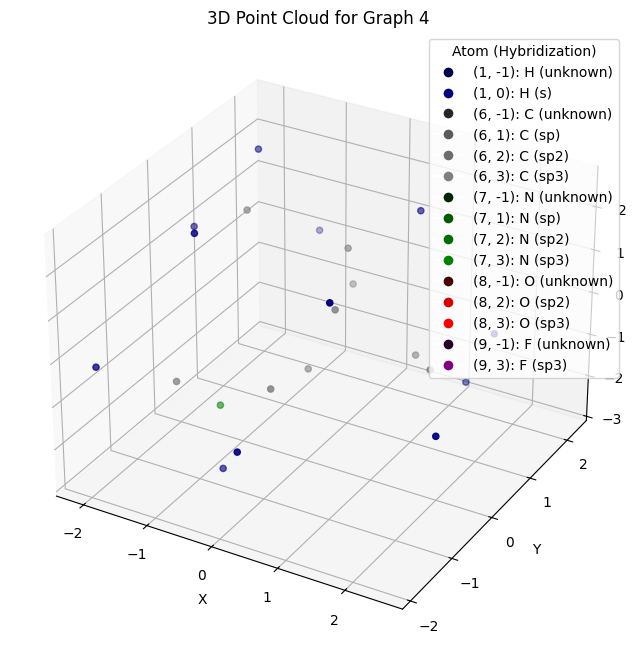

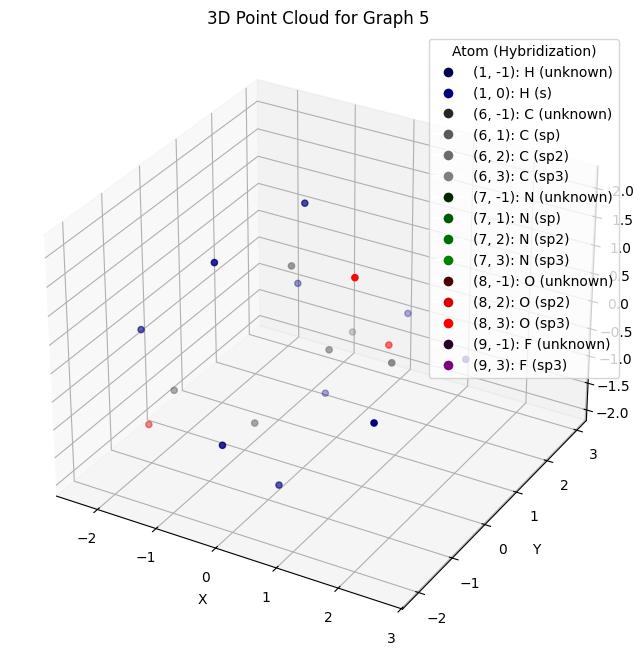

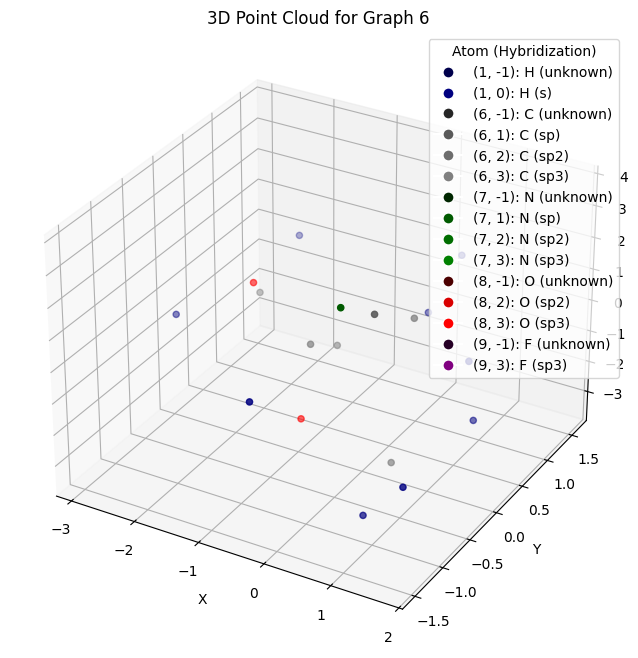

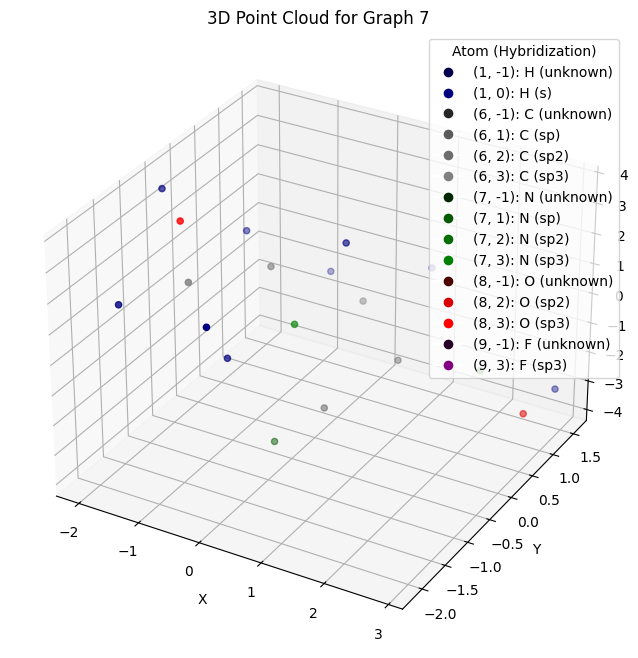

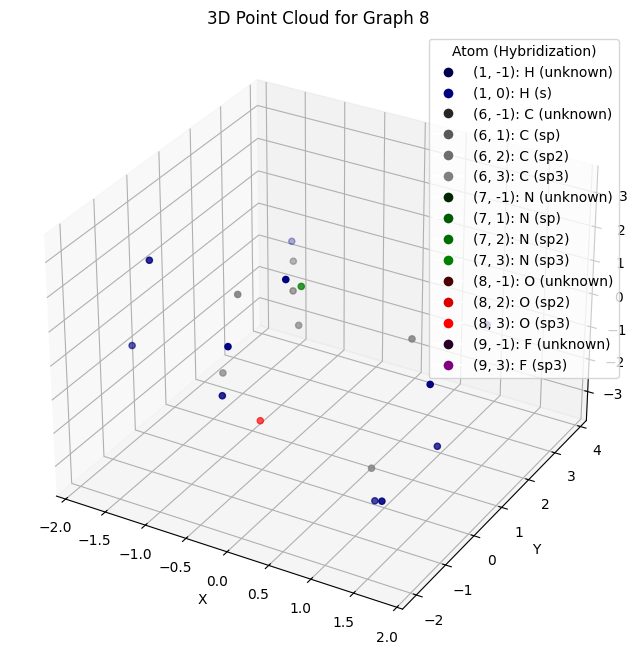

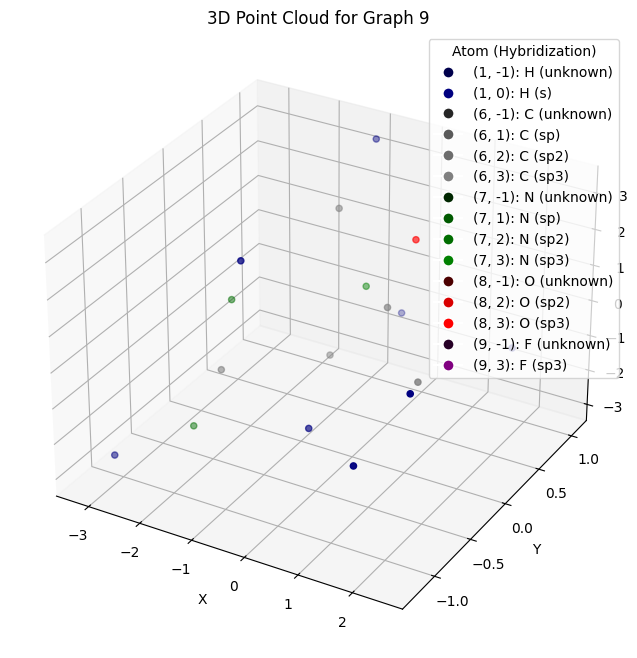

In [4]:
visualize_point_clouds(f'{root}x_10.pt', 
                       f'{root}pos_10.pt', 
                       f'{root}batch_source_10.pt')

In [16]:
import torch
import py3Dmol

def visualize_point_clouds_py3dmol(x_file, pos_file, batch_file, b):
    """
    Visualizes 3D point clouds stored in PyTorch .pt files using py3Dmol for interactive visualization.

    Args:
        x_file (str): Path to the .pt file containing point types (integers).
        pos_file (str): Path to the .pt file containing point positions (3D coordinates).
        batch_file (str): Path to the .pt file containing batch assignments (integers).
    """
    # Mapping of point types to atom symbols
    type_mapping = {
        1: "H",
        2: "H",
        3: "C",
        4: "C",
        5: "C",
        6: "C",
        7: "N",
        8: "N",
        9: "N",
        10: "N",
        11: "O",
        12: "O",
        13: "O",
        14: "F",
        15: "F"
    }

    # Load the data from .pt files
    x = torch.load(x_file).detach().cpu()  # Point types (integers)
    pos = torch.load(pos_file).detach().cpu()  # Point positions (3D coordinates)
    batch = torch.load(batch_file).detach().cpu()  # Batch assignments (integers)

    # Ensure the data is in the correct format
    assert pos.shape[1] == 3, "Positions should have 3 columns (x, y, z)."
    assert len(x) == len(pos) == len(batch), "Mismatch in data lengths."

    # Get the unique batch indices (graphs)
    unique_batches = torch.unique(batch)

    # Visualize each batch (graph) separately
    # Filter points belonging to the current batch
    mask = batch == b
    points = pos[mask]
    types = x[mask]

    # Generate XYZ format string
    xyz_data = f"{len(points)}\nGraph {b}\n"
    for i in range(len(points)):
        atom_type = type_mapping.get(types[i].item(), "X")  # Default to "X" for unknown types
        x, y, z = points[i].tolist()
        xyz_data += f"{atom_type} {x:.4f} {y:.4f} {z:.4f}\n"

    # Create a py3Dmol viewer
    view = py3Dmol.view(width=800, height=600)
    view.addModel(xyz_data, "xyz")  # Add the XYZ data to the viewer
    view.setStyle({"sphere": {"scale": 0.3}})  # Set style to spheres
    view.zoomTo()  # Automatically zoom to fit the molecule
    view.show()  # Display the viewer

    # Pause for user interaction
        #input("Press Enter to continue to the next graph...")

In [30]:
visualize_point_clouds_py3dmol(f'{root}x_10.pt', 
                            f'{root}pos_10.pt', 
                            f'{root}batch_source_10.pt', 9)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.